# Hazard

In this notebook we read in Hazard data from a raster file, break down its properties and plot it.

CLIMADA describes hazards as one or more (and maybe thousands) of event footprints in a file. Each event in a Hazard object is a geospatial footprint – usually an event footprint (e.g. a historical flood depth reconstruction, or a month's simulated drought index) or a statistical summary – usually a return period footprint (e.g. the 10-year return period wind speed).

Every event has an ID and a frequency describing how often it occurs within the framework of the analysis (e.g. annual, or 1-in-100 year probability). Together these can describe a case study, a historical event set, a daily time series, a stochastic event set, or more. 

Each event footprint is defined on an underlying set of Centroids – an object containing a geodataframe of points, ensuring that all hazards are defined at the same locations (events can have zero or missing values).

Centroids are often a regular grid but don't have to be: they can be daily climate model output, or hazard interpolated to the locations of your exposures, or defined at the locations of weather stations, or on a variable resolution grid that gives more detail in more complex or more exposed areas. Usually these will be inferred from the data source, but sometimes you need to specify them.

Hazards are in the `climada.hazard` package's `Hazard` class and Centroids in the package's `Centroids` class.

Hazards are stored either as .hdf5 files, written and read with CLIMADA's own format, or (when the hazard is on a regular grid) as .tif raster files or in an xarray-compatible format (e.g. NetCDF, HDF5). In the case of a .tif file you will need to provide additional metadata when you read in the file (even IDs, event frequencies, etc).


## Hazards from raster files

Let's read in a raster file. You can provide a single .tif with one band for each event, or a separate .tifs file for each event.

In this notebook we have one event: the 2024 Porto Alegre flood that we're reconstructing. The .tif file contains reconstructed information on the flood duration in days.

In [1]:
from climada.hazard import Hazard
from pathlib import Path

HAZARD_DIR = "../data/hazard/"
HAZARD_FILE = "Brazil_Porto_Alegre_2024_duration.tif"

haz_filepath = Path(HAZARD_DIR) / HAZARD_FILE

In [2]:
import copy
import numpy as np
from climada.hazard import Hazard

# Read in the hazard data
haz = Hazard.from_raster(
        files_intensity = haz_filepath,
        attrs={
            'unit': 'days',
            'event_name': ["2024 Flood"],     # We can optionally name the events
            'frequency': [1]                  # With one event we don't do a probabilistic analysis: the frequency is 1 (i.e. it will happen every year).
        },
        haz_type='FL',
        window=None,          # Only read a window from the raster datasets, provided as a rasterio.windows.Windows object 
        geometry=None,        # Only read within a given geometry, provided as a list of shapely.geometry objects
)


2026-07-03 09:37:53,301 - climada.util.coordinates - INFO - Reading ../data/hazard/Brazil_Porto_Alegre_2024_duration.tif
2026-07-03 09:37:55,092 - climada.util.coordinates - INFO - Reading ../data/hazard/Brazil_Porto_Alegre_2024_duration.tif


In [3]:
# Print some properties of the hazard

print("Hazard properties:")
print(f"Number of events: {haz.size}")
print(f"Number of centroids at which the hazard is defined: {haz.centroids.size}")
print(f"Hazard CRS: {haz.centroids.crs}")
print(f"Latitude range: ({haz.centroids.lat.min():.2f}, {haz.centroids.lat.max():.2f})")
print(f"Longitude range: ({haz.centroids.lon.min():.2f}, {haz.centroids.lon.max():.2f})")
print(f"Minimum intensity: {haz.intensity.min()} {haz.units}")
print(f"Maximum intensity: {haz.intensity.max()} {haz.units}")
print(f"Minimum fraction: {haz.fraction.min()}")
print(f"Maximum fraction: {haz.fraction.max()}")
print(f"Event frequencies ({haz.frequency_unit}): {haz.frequency}")

Hazard properties:
Number of events: 1
Number of centroids at which the hazard is defined: 1354664
Hazard CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Latitude range: (-30.27, -29.93)
Longitude range: (-51.30, -51.01)
Minimum intensity: 0.0 days
Maximum intensity: 91.0 days
Minimum fraction: 0.0
Maximum fraction: 1.0
Event frequencies (1/year): [1]


## Plotting hazards

We can visualise hazards using methods in the `Hazard` class. This hazard is defined on an underlying regular grid:

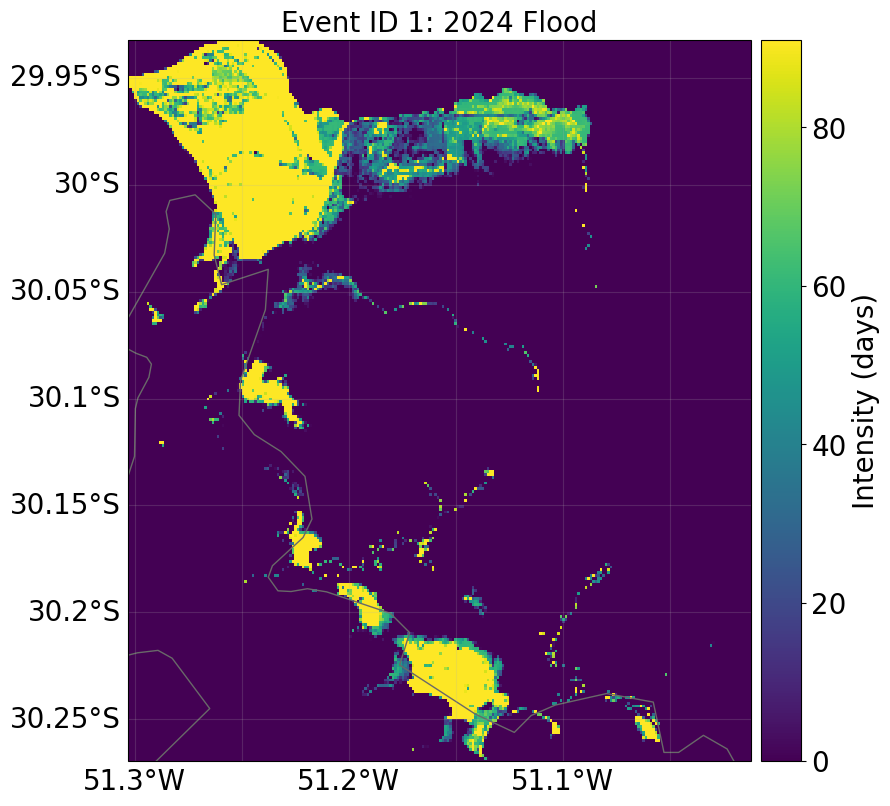

In [4]:
%matplotlib inline
from matplotlib import pyplot as plt

# Plot the hazard intensities (this takes a long time and the plots below are more informative):
_ = haz.plot_intensity(event=1)         # event = 1 plots the first (and only) event

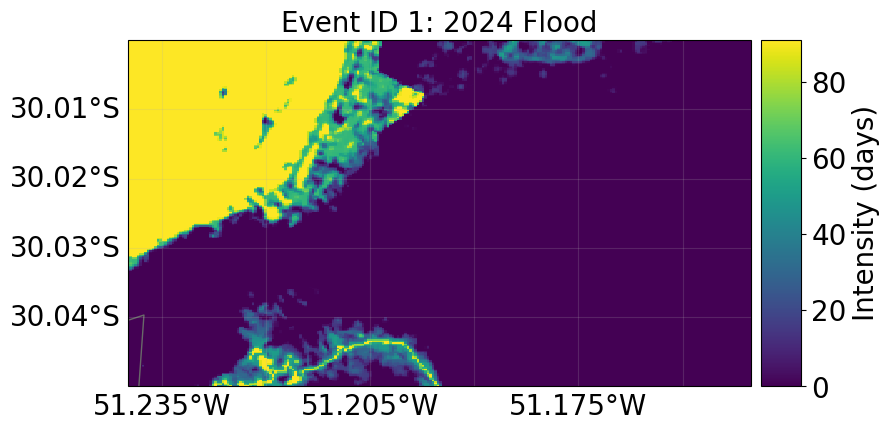

In [5]:
# Let's zoom in and plot some smaller areas:

sample_region = (-51.24, -51.15, -30.05, -30.00)  # (min_lon, max_lon, min_lat, max_lat)
lon_min, lon_max, lat_min, lat_max = sample_region

haz_sample = copy.deepcopy(haz)
haz_sample = haz_sample.select(extent=sample_region)

_ = haz_sample.plot_intensity(event=1)

## Hazard object structure

The Hazard is defined through a few key properties:
- `centroids`: a CLIMADA Centroids object, which specifies the geographic points on which the hazard's events are all defined
- `intensity`: a sparse matrix, with dimensions (number of events) x (number of centroids), specifying the intensity of the hazard for each location and each event. (A sparse matrix is an efficient way to store matrices where many entries might be zero, which is the case for many hazards, including floods)
- `fraction`: another sparse matrix with the same dimensions, this time specifying the fraction of the assets affected by each event at each location. In this study we assume that all exposures are affected, so this matrix isn't required.
- `frequency`: an array giving the probabilistic frequency of each event. We defined these above

The underlying centroids can be visualized:

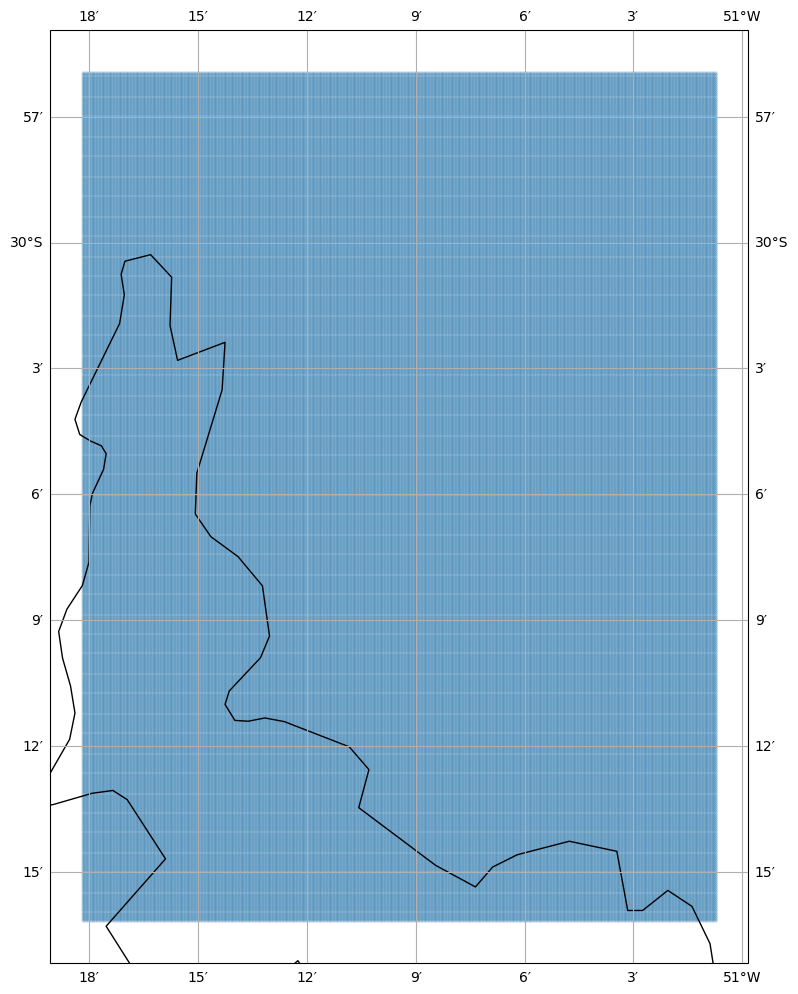

In [6]:
_ = haz.centroids.plot(markersize=0.003)

**Note:** In the Starter Pack for Peru, we subset the Hazard to include only Centroids that have a hazard > 0. This is because centroids without hazard are unhelpful in the analysis (since the flood hazard shows street-level flooding, with building rooftops unaffected: we wanted to remove centroids corresponding to the rooftops). The flood footprint here is different, and zero-valued hazard is valuable to include, since it shows us locations that were _not_ flooded, which we want to know.